In [9]:
!pip install givernylocal

In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from givernylocal.turbulence_dataset import turb_dataset
from givernylocal.turbulence_toolkit import getCutout
from scipy.ndimage import gaussian_filter

In [11]:
cube = turb_dataset(
    dataset_title="isotropic1024coarse",
    output_path="./jhtdb_output",
    auth_token="edu.gatech.jerrychen-6b7455a7"
)

axes_ranges = np.array([
    [1,16],
    [1,16],
    [1,16],
    [1,1]
])

strides = np.array([1,1,1,1])

cutout = getCutout(
    cube,
    var="velocity",
    xyzt_axes_ranges_original=axes_ranges,
    xyzt_strides=strides
)


-----
getCutout is processing...

total time elapsed = 0.412 seconds (0.007 minutes)

query completed successfully.
-----


In [12]:
velocity = cutout["velocity_0001"].values

speed = np.sqrt(
    velocity[:,:,:,0]**2 +
    velocity[:,:,:,1]**2 +
    velocity[:,:,:,2]**2
)

print("High-res shape:", speed.shape)

High-res shape: (16, 16, 16)


In [13]:
sigma = 1.0

speed_filtered = gaussian_filter(speed, sigma=sigma)

speed_low = speed_filtered[::2, ::2, ::2]

print("Low-res shape:", speed_low.shape)

Low-res shape: (8, 8, 8)


In [14]:
from scipy.ndimage import zoom

speed_low_up = zoom(speed_low, zoom=2, order=1)

print(speed_low_up.shape)

(16, 16, 16)


In [15]:
def build_3d_grid_graph(nx, ny, nz):
    edges = []

    def idx(i,j,k):
        return i*ny*nz + j*nz + k

    for i in range(nx):
        for j in range(ny):
            for k in range(nz):

                neighbors = [
                    (i+1,j,k),(i-1,j,k),
                    (i,j+1,k),(i,j-1,k),
                    (i,j,k+1),(i,j,k-1),
                ]

                for ni,nj,nk in neighbors:
                    if 0<=ni<nx and 0<=nj<ny and 0<=nk<nz:
                        edges.append([idx(i,j,k), idx(ni,nj,nk)])

    return torch.tensor(edges).t().contiguous()

In [16]:
nx, ny, nz = speed.shape

edge_index = build_3d_grid_graph(nx,ny,nz)

x = torch.tensor(speed_low_up.reshape(-1,1), dtype=torch.float)
y = torch.tensor(speed.reshape(-1,1), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, y=y)

In [17]:
class SimpleGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(1,32)
        self.conv2 = GCNConv(32,32)
        self.conv3 = GCNConv(32,1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)

        return x

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleGNN().to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(200):
    optimizer.zero_grad()

    pred = model(data)
    loss = loss_fn(pred, data.y)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(epoch, loss.item())

0 0.655428409576416
20 0.13408559560775757
40 0.013559972867369652
60 0.012758046388626099
80 0.012166731990873814
100 0.011500434949994087
120 0.010792985558509827
140 0.01007184386253357
160 0.009374383836984634
180 0.008744314312934875


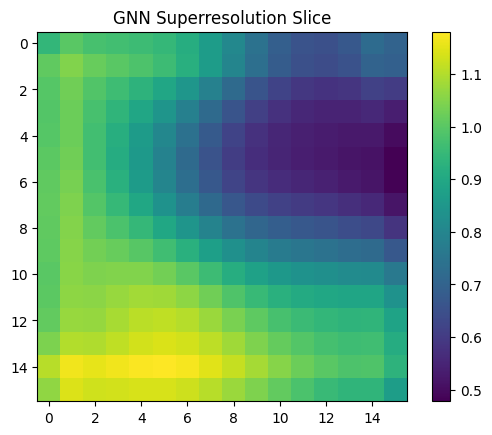

In [19]:
model.eval()

with torch.no_grad():
    pred = model(data).cpu().numpy()

pred_field = pred.reshape(nx,ny,nz)

plt.imshow(pred_field[:,:,8])
plt.title("GNN Superresolution Slice")
plt.colorbar()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_16200\3594353478.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


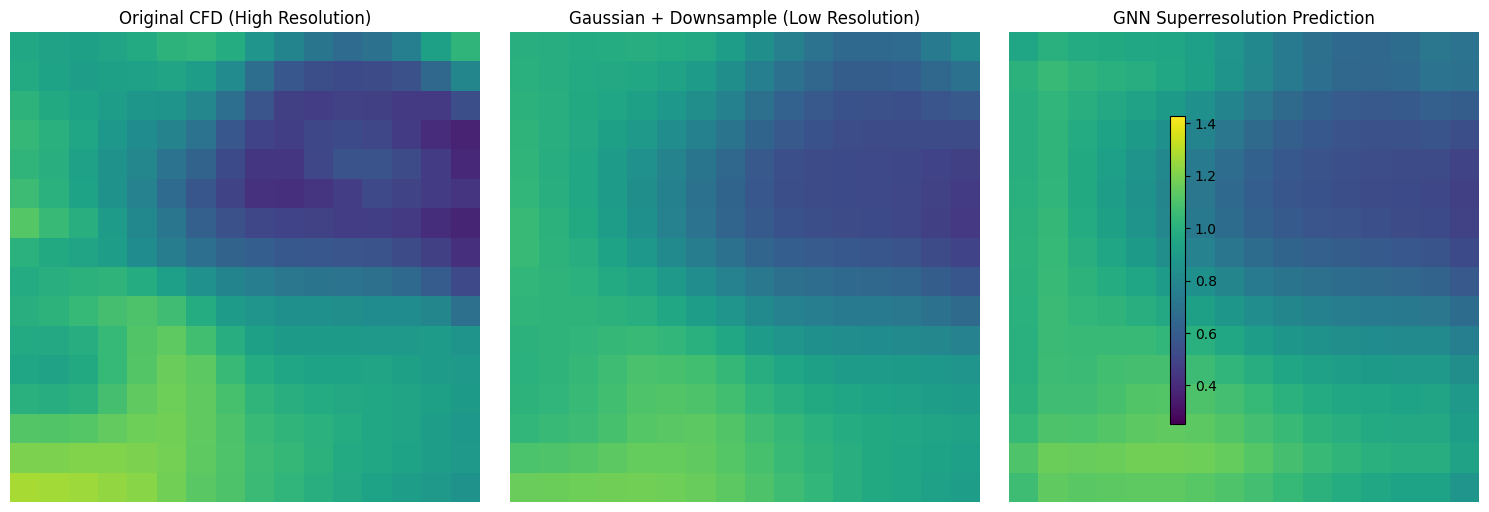

In [20]:
hr_field = speed                  # original CFD
lr_field = speed_low_up           # degraded + upsampled
gnn_field = pred_field            # prediction

slice_idx = nz // 2

fig, axes = plt.subplots(1, 3, figsize=(15,5))

vmin = hr_field.min()
vmax = hr_field.max()

# --- Original CFD ---
im0 = axes[0].imshow(hr_field[:,:,slice_idx],
                     vmin=vmin, vmax=vmax)
axes[0].set_title("Original CFD (High Resolution)")
axes[0].axis("off")

# --- Low Resolution ---
im1 = axes[1].imshow(lr_field[:,:,slice_idx],
                     vmin=vmin, vmax=vmax)
axes[1].set_title("Gaussian + Downsample (Low Resolution)")
axes[1].axis("off")

# --- GNN Prediction ---
im2 = axes[2].imshow(gnn_field[:,:,slice_idx],
                     vmin=vmin, vmax=vmax)
axes[2].set_title("GNN Superresolution Prediction")
axes[2].axis("off")

fig.colorbar(im2, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

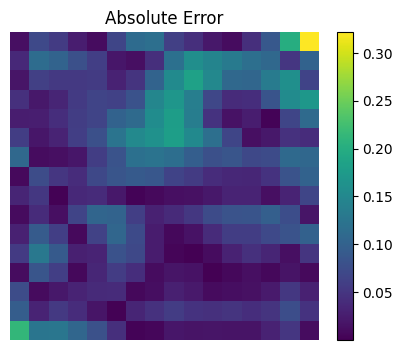

In [21]:
error = np.abs(hr_field - gnn_field)

plt.figure(figsize=(5,4))
plt.imshow(error[:,:,slice_idx])
plt.title("Absolute Error")
plt.colorbar()
plt.axis("off")
plt.show()